# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [9]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [10]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
kart = pd.read_csv("SuperKart.csv")

In [13]:
data = kart.copy()
data

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36
...,...,...,...,...,...,...,...,...,...,...,...,...
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82


# **Data Overview**

In [14]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [15]:
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [16]:
data.shape

(8763, 12)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [18]:
data.describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [21]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

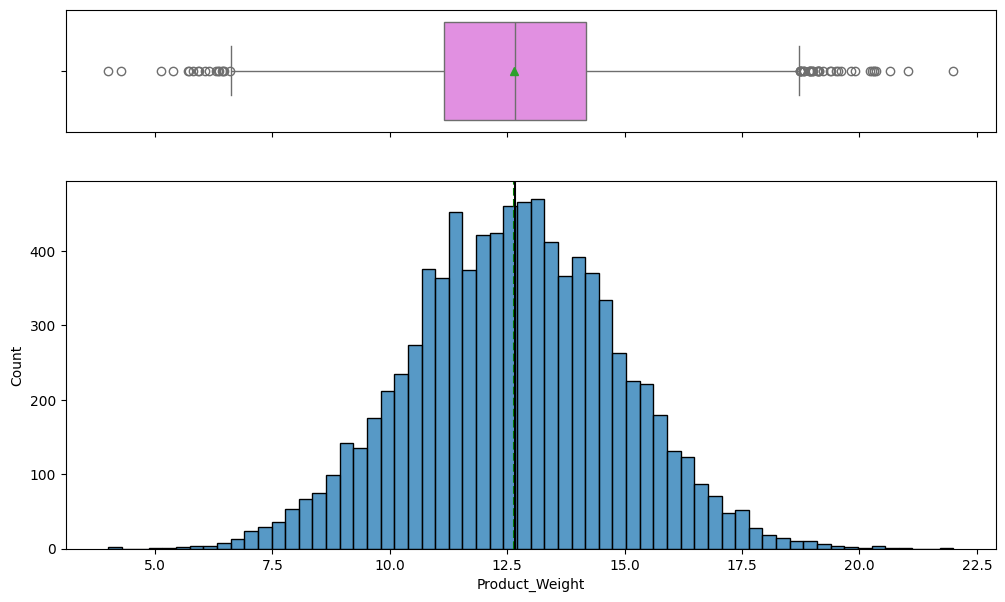

In [22]:
histogram_boxplot(data, "Product_Weight")     #To plot the boxplot and histogram of Product_Weight

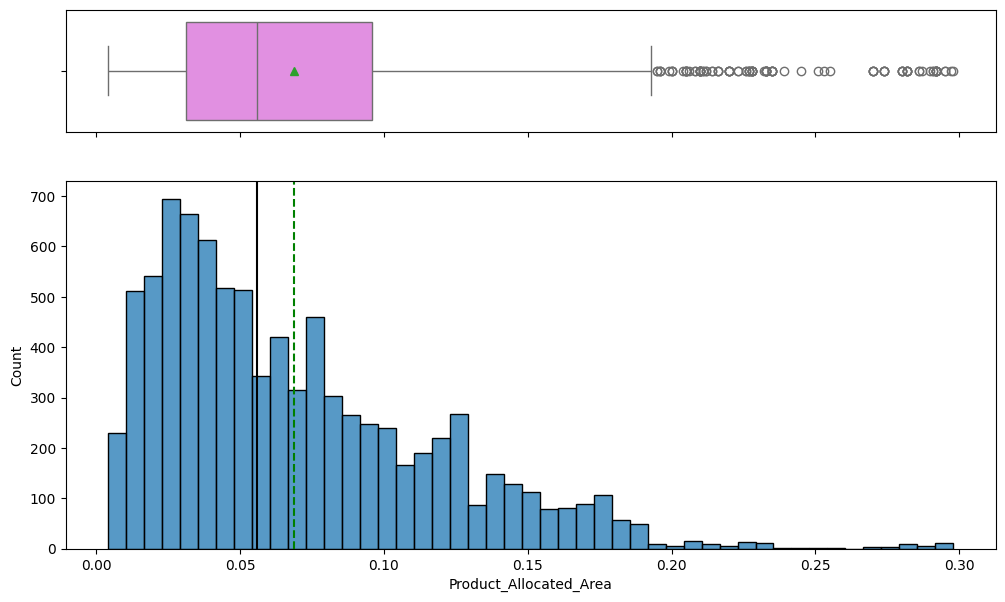

In [23]:
histogram_boxplot(data, "Product_Allocated_Area")     #To plot the boxplot and histogram of Product_Allocated_Area

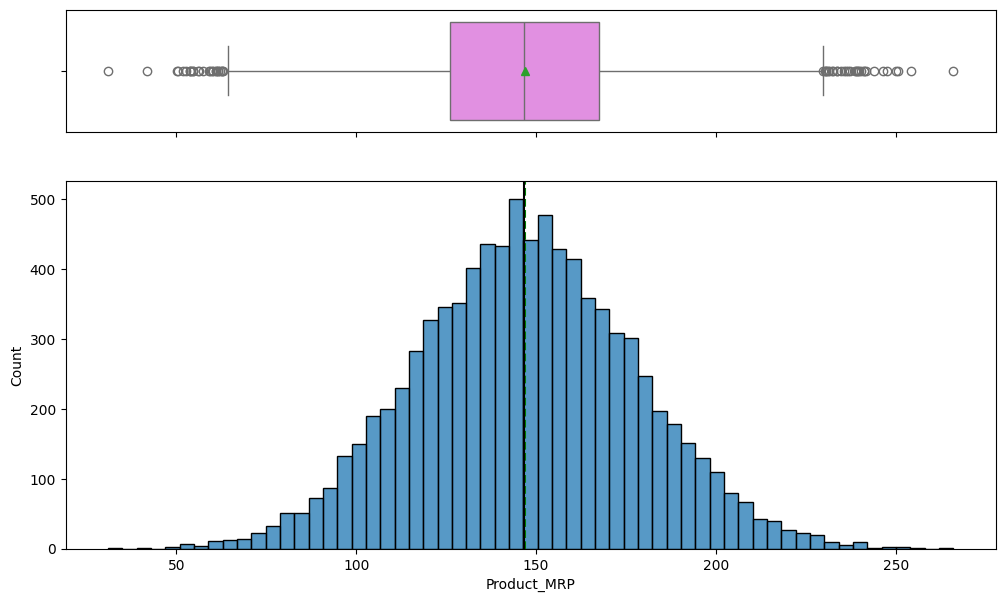

In [24]:
histogram_boxplot(data, "Product_MRP")    #To plot the boxplot and histogram of Product_MRP

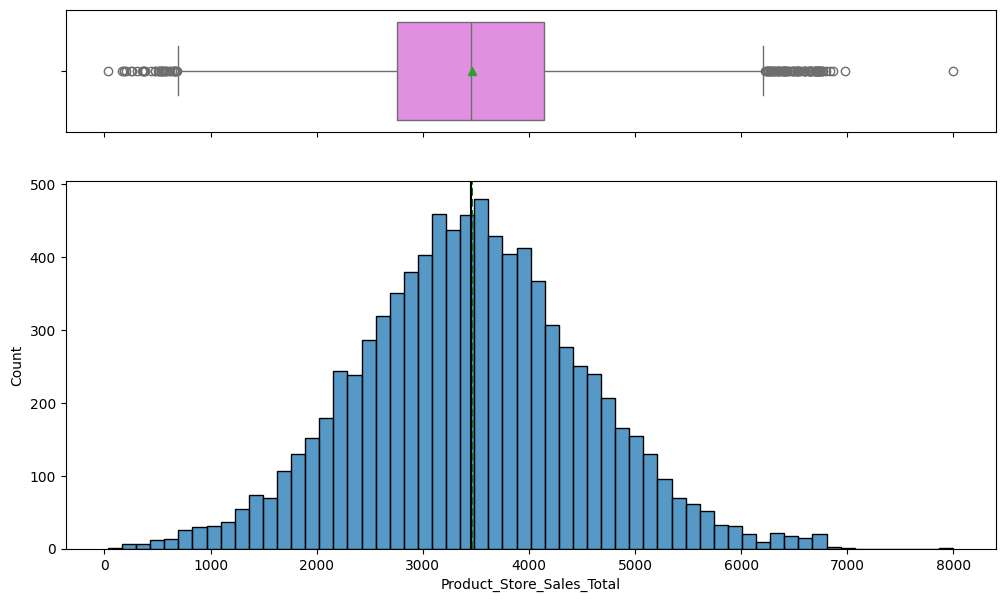

In [25]:
histogram_boxplot(data, "Product_Store_Sales_Total")      #To plot the boxplot and histogram of Product_Store_Sales_Total

In [26]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

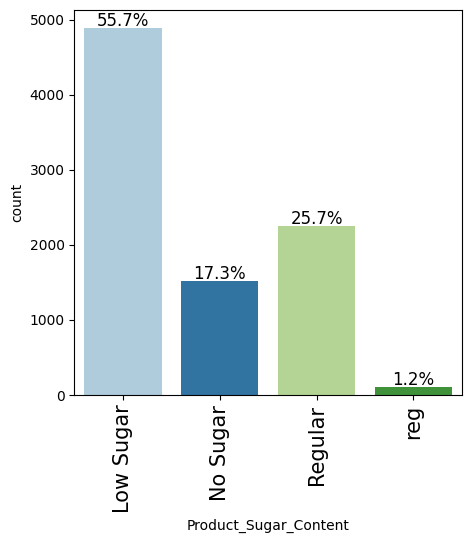

In [27]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)   #To plot the labelled barplot of Product_Sugar_Content with the percentages being displayed

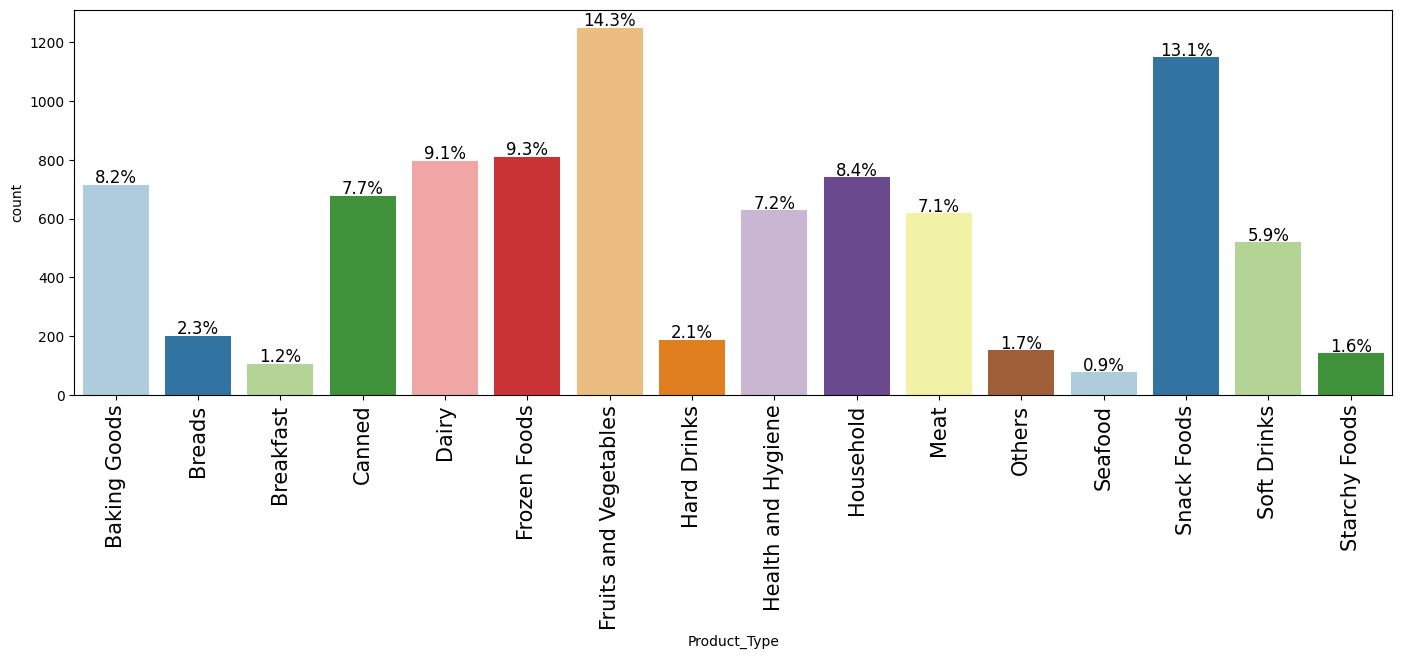

In [28]:
labeled_barplot(data, "Product_Type", perc=True)      #To plot the labelled barplot of Product_Type with the percentages being displayed

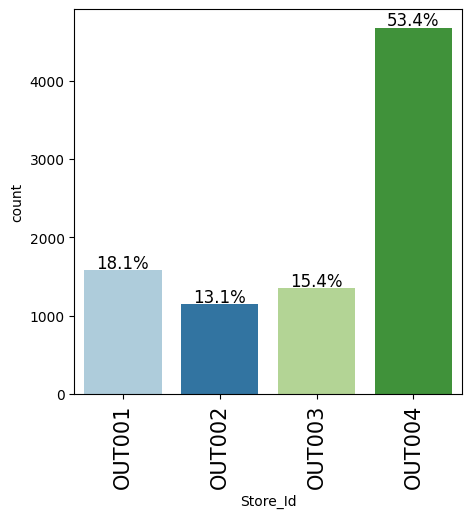

In [29]:
labeled_barplot(data, "Store_Id", perc=True)    #To plot the labelled barplot of Store_Id with the percentages being displayed

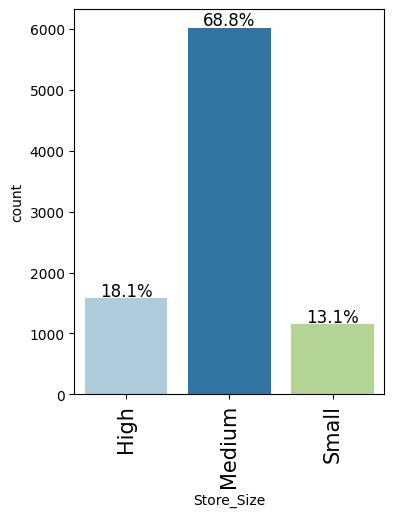

In [30]:
labeled_barplot(data, "Store_Size", perc=True)    #To plot the labelled barplot of Store_Size with the percentages being displayed

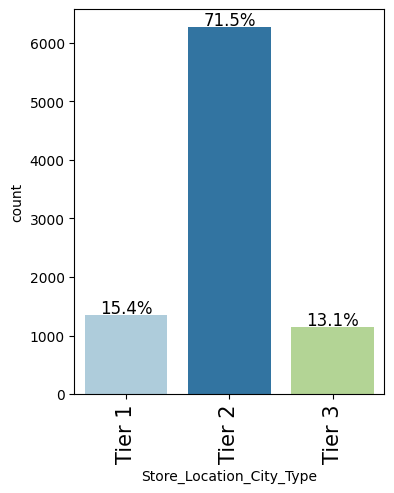

In [31]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)    #To plot the labelled barplot of Store_Location_City_Type with the percentages being displayed

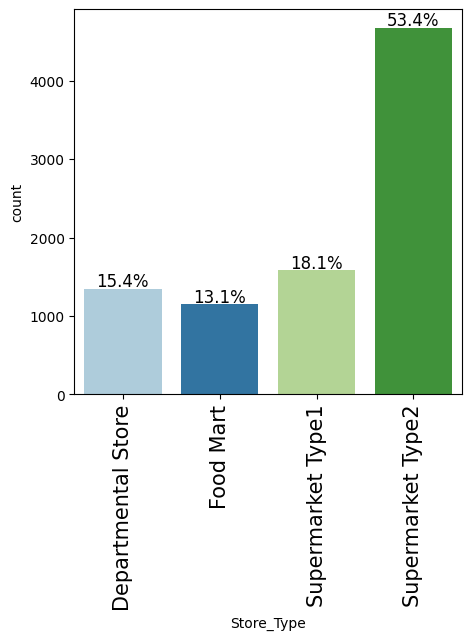

In [32]:
labeled_barplot(data, "Store_Type", perc=True)    #To plot the labelled barplot of Store_Type with the percentages being displayed

## Bivariate Analysis

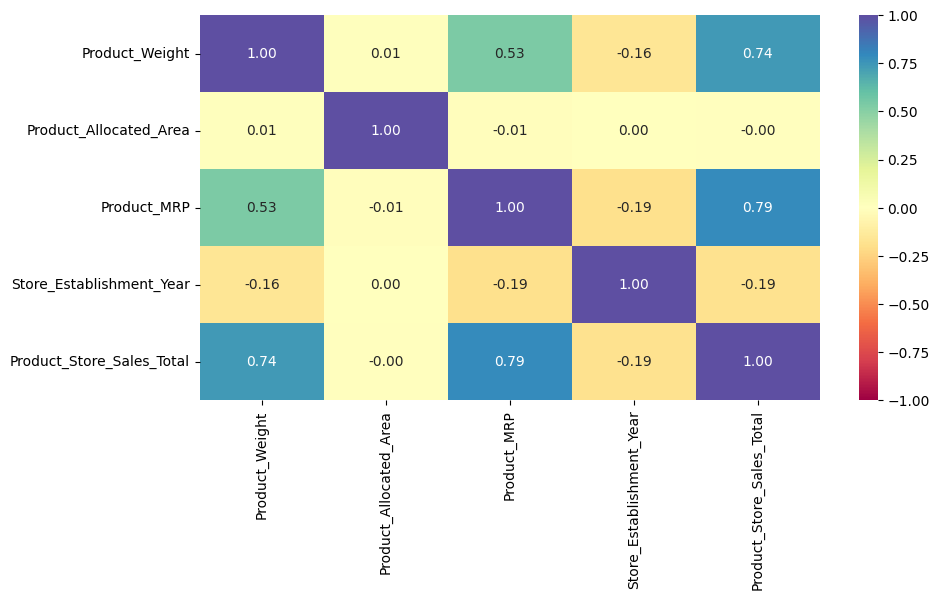

In [33]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

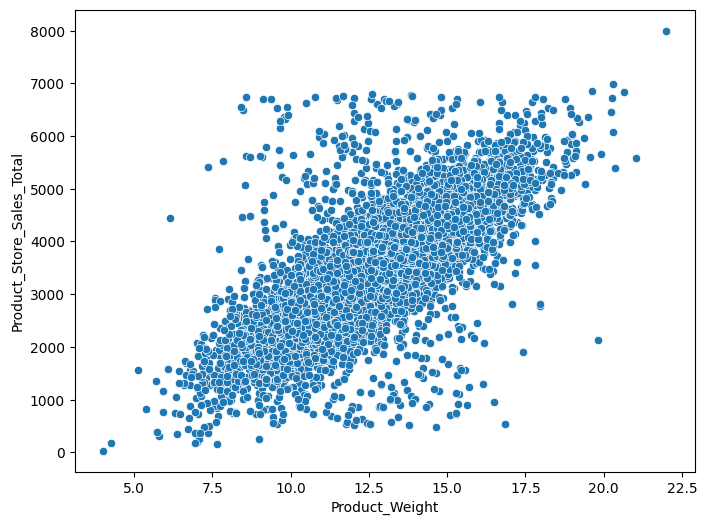

In [34]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)    #To plot a scatterplot of Product_Weight and Product_Store_Sales_Total
plt.show()

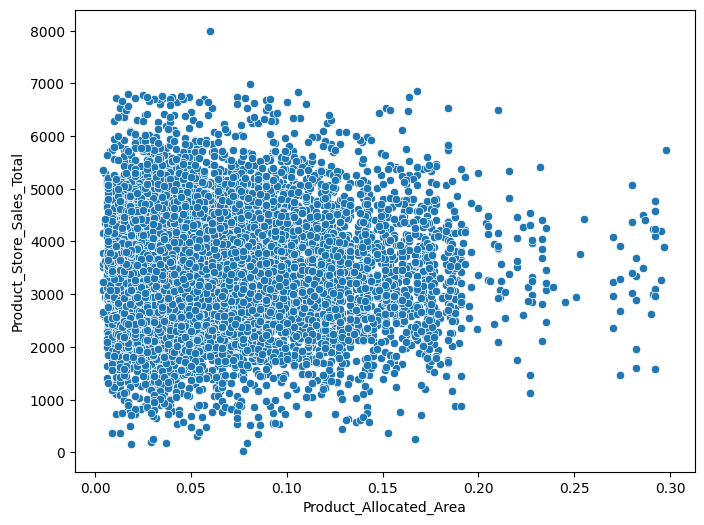

In [35]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x='Product_Allocated_Area', y='Product_Store_Sales_Total', data=data) #To plot a scatterplot of Product_Allocated_Area and Product_Store_Sales_Total
plt.show()

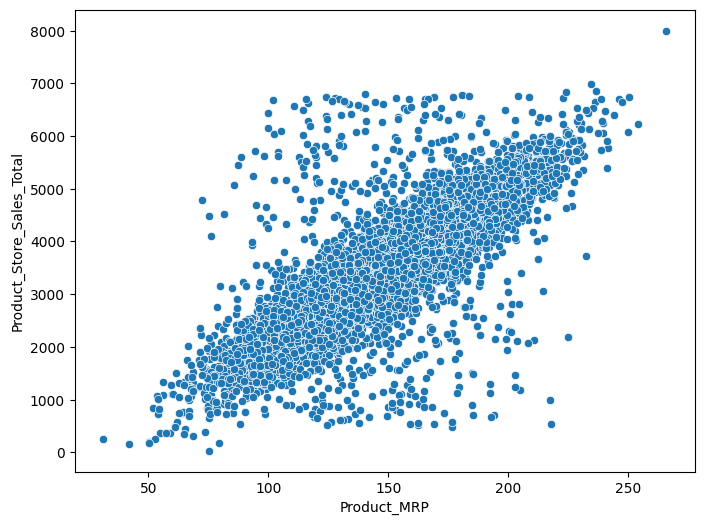

In [36]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x='Product_MRP', y='Product_Store_Sales_Total',data=data) #To plot a scatterplot of Product_MRP and Product_Store_Sales_Total
plt.show()

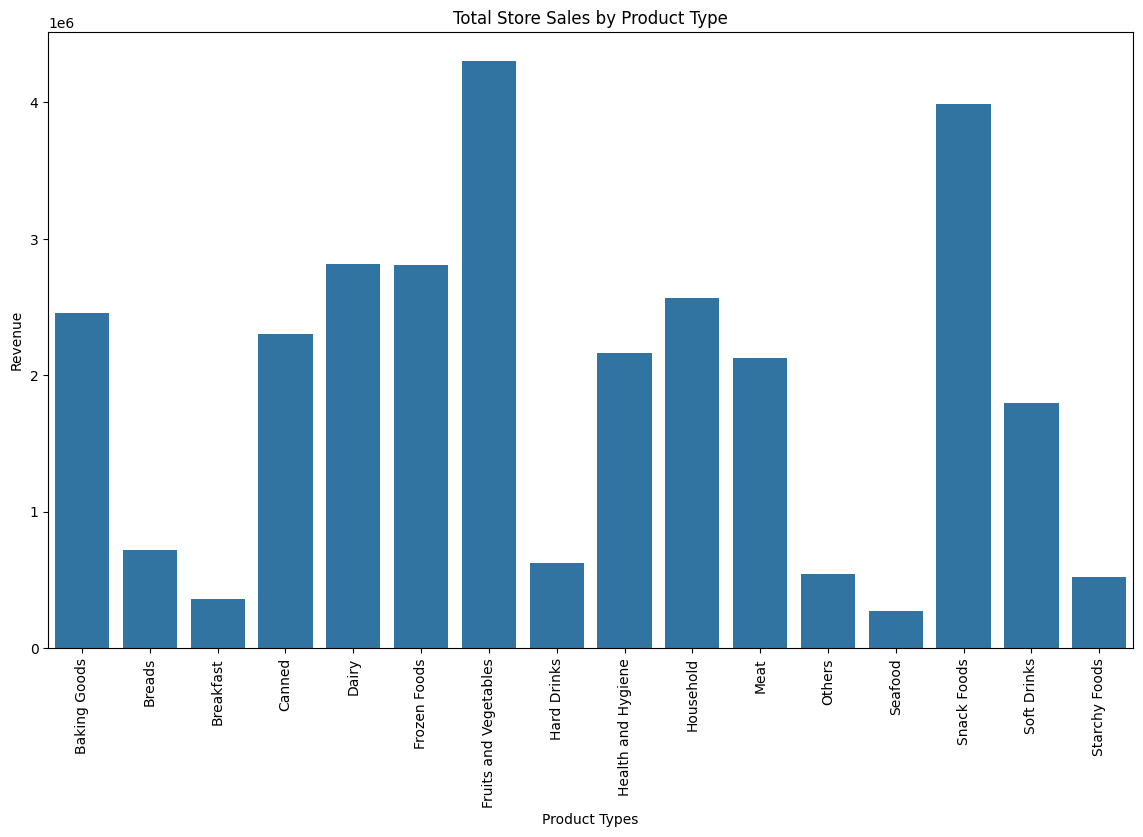

In [37]:
# Grouping the data by Product_Type and summing the total sales
df_revenue1 = data.groupby("Product_Type", as_index=False)["Product_Store_Sales_Total"].sum()

# Setting the figure size
plt.figure(figsize=[14, 8])

# Rotating x-axis labels for better readability
plt.xticks(rotation=90)

# Creating the bar plot
a = sns.barplot(x='Product_Type', y='Product_Store_Sales_Total', data=df_revenue1)

# Adding axis labels
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
a.set_title("Total Store Sales by Product Type")

# Display the plot
plt.show()


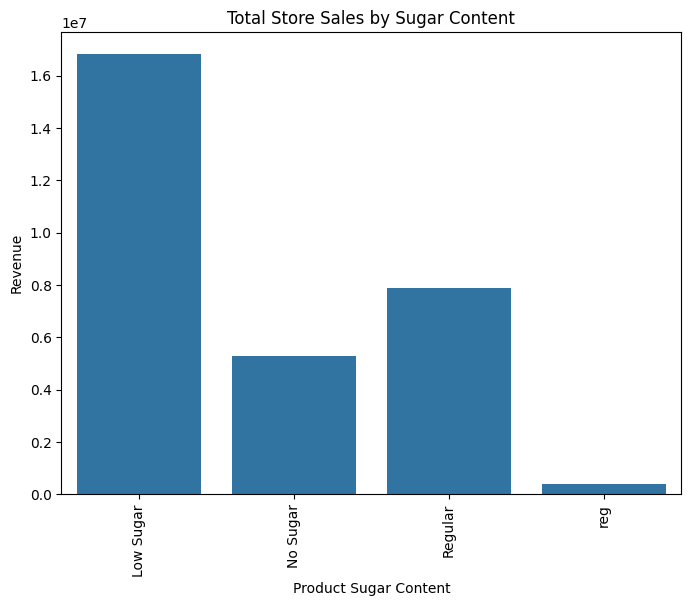

In [38]:
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)

b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product Sugar Content")
b.set_ylabel("Revenue")
b.set_title("Total Store Sales by Sugar Content")
plt.show()


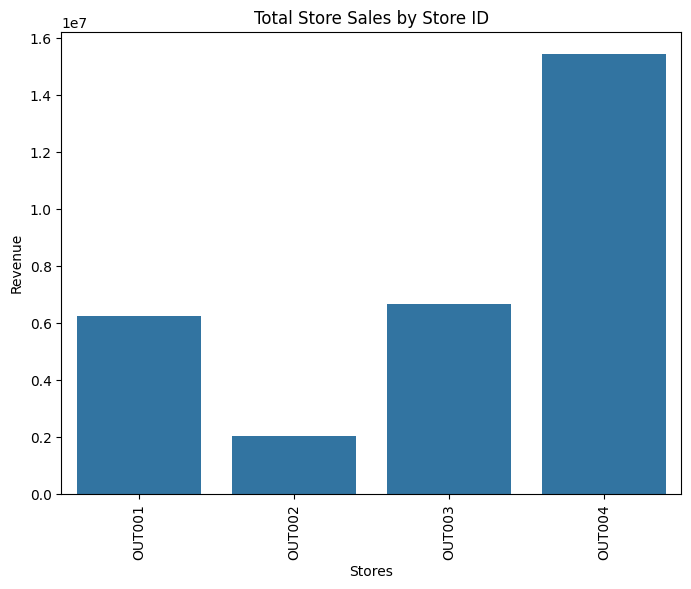

In [39]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)

r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
r.set_title("Total Store Sales by Store ID")
plt.show()


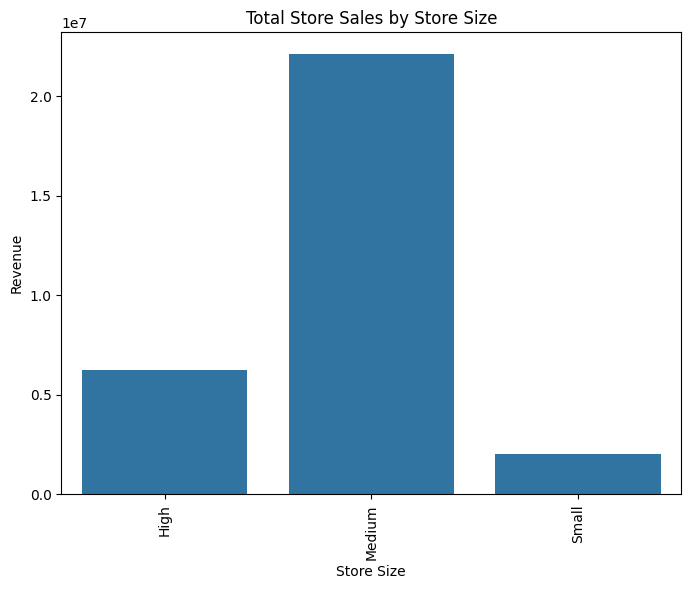

In [40]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)

c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store Size")
c.set_ylabel("Revenue")
c.set_title("Total Store Sales by Store Size")
plt.show()


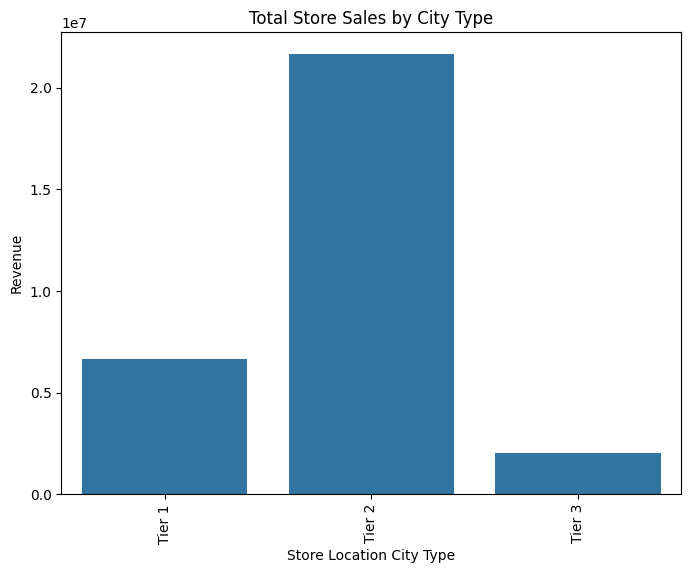

In [41]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)

d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store Location City Type")
d.set_ylabel("Revenue")
d.set_title("Total Store Sales by City Type")
plt.show()


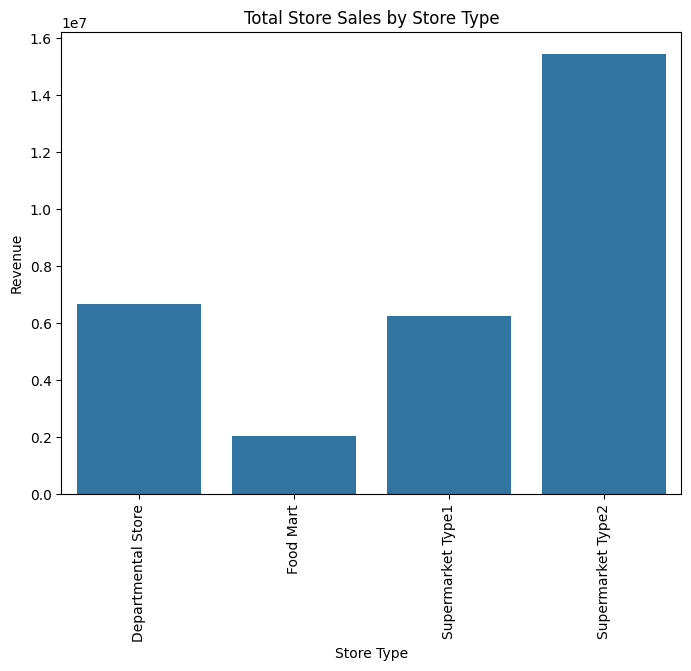

In [42]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)

e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store Type")
e.set_ylabel("Revenue")
e.set_title("Total Store Sales by Store Type")
plt.show()


In [43]:
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,NC7187,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,4,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

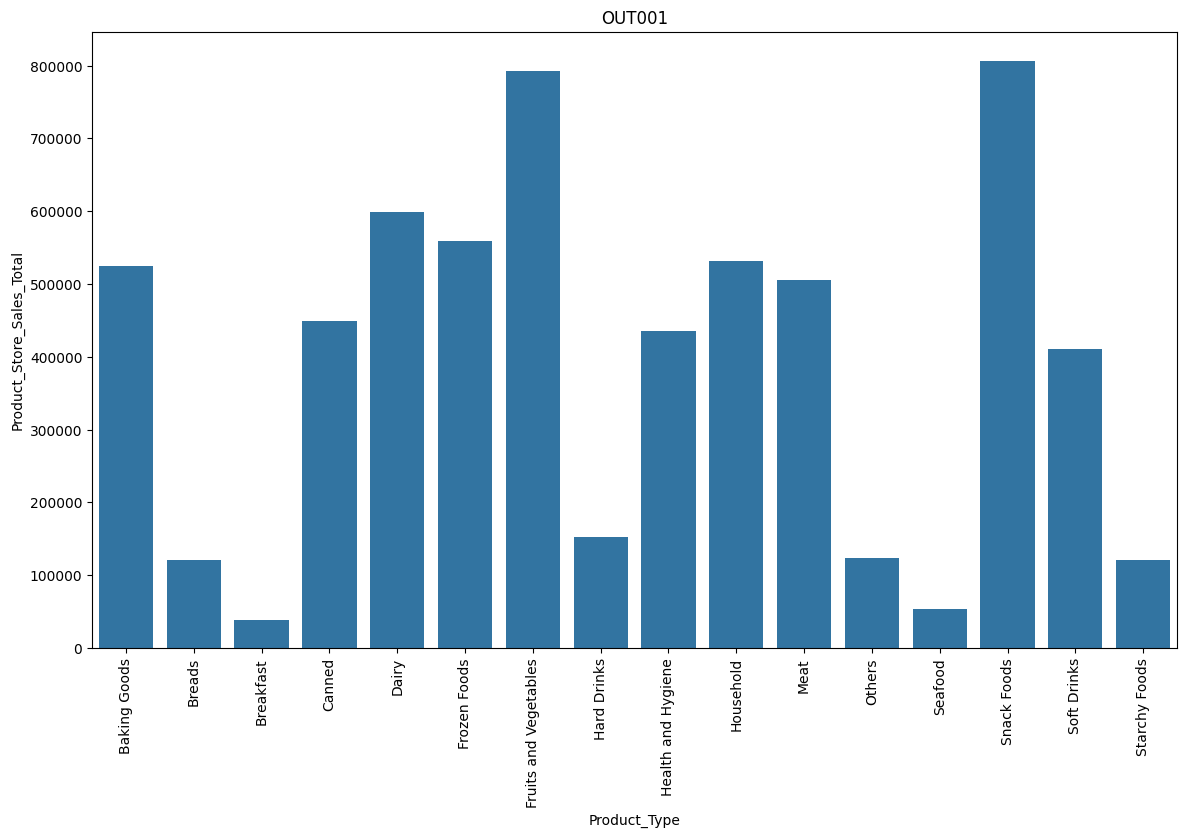

In [45]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

# **Data Preprocessing**

In [46]:
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [47]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


In [48]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [49]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [50]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

In [51]:
data.loc[data.Product_Id_char == "_____+", "Product_Type"].unique() #To select the rows where Product_Id_char is DR

array([], dtype=object)

In [52]:
data.loc[data.Product_Id_char == "_____", "Product_Type"].unique() #To select the rows where Product_Id_char is NC

array([], dtype=object)

In [53]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

In [54]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [55]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [56]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [57]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


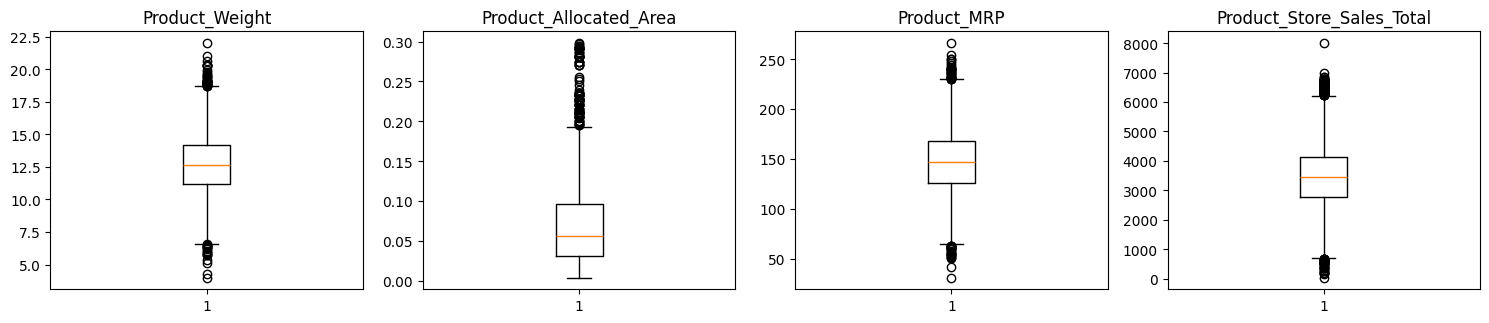

In [58]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [59]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [60]:
data = data.drop(["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"], axis=1)


In [61]:
data.shape

(8763, 11)

In [62]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [63]:
# Separating features and the target column
X = data.drop("Product_Store_Sales_Total", axis=1)  # dropping the target from features
y = data["Product_Store_Sales_Total"]               # selecting the target column


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True
)


In [65]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

In [66]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [67]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

In [68]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

**Decision Tree**

In [69]:
# Decision Tree

dtree = DecisionTreeRegressor(random_state=1)
dtree = make_pipeline(preprocessor,dtree)
dtree.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=1))])

In [70]:
dtree_model_train_perf = model_performance_regression(dtree, X_train, y_train)
dtree_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965498,0.685033,0.684519,0.16569


In [71]:
dtree_model_test_perf = model_performance_regression(dtree, X_test, y_test)
dtree_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429583,0.668482,0.667215,0.187421


**Bagging**

In [72]:
bagging_regressor = BaggingRegressor(random_state=1)
bagging_regressor = make_pipeline(preprocessor,bagging_regressor)
bagging_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor', BaggingRegressor(random_state=1))])

In [73]:
bagging_regressor_model_train_perf = model_performance_regression(bagging_regressor, X_train, y_train)
bagging_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.064588,469.426208,0.684942,0.684428,0.165799


In [74]:
bagging_regressor_model_test_perf = model_performance_regression(bagging_regressor, X_test, y_test)
bagging_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.866125,485.588892,0.668554,0.667288,0.18735


**Random Forest**

In [75]:
rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(preprocessor,rf_estimator)
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

In [76]:
rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.994959,468.87585,0.685016,0.684501,0.165674


In [77]:
rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.906846,485.311027,0.66851,0.667244,0.187394


**Ada Boost**

In [78]:
ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor = make_pipeline(preprocessor,ab_regressor)
ab_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor', AdaBoostRegressor(random_state=1))])

In [79]:
ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
ab_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,627.778405,512.191947,0.651694,0.651126,0.172981


In [80]:
ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
ab_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,647.483018,530.557049,0.633649,0.63225,0.193723


**Gradient Boosting**

In [81]:
gb_estimator = GradientBoostingRegressor(random_state=1)
gb_estimator = make_pipeline(preprocessor,gb_estimator)
gb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=1))])

In [82]:
gb_estimator_model_train_perf = model_performance_regression(gb_estimator, X_train, y_train)
gb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.006101,469.061969,0.685004,0.684489,0.16573


In [83]:
gb_estimator_model_test_perf = model_performance_regression(gb_estimator, X_test, y_test)
gb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.902369,485.444821,0.668515,0.667249,0.187447


**Xgboost**

In [84]:
xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator = make_pipeline(preprocessor,xgb_estimator)
xgb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

In [85]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965507,0.685033,0.684519,0.16569


In [86]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429585,0.668482,0.667215,0.187421


# **Model Performance Improvement - Hyperparameter Tuning**

**Descision Tree**

In [87]:
dtree_tuned = DecisionTreeRegressor(random_state=1)
dtree_tuned = make_pipeline(preprocessor, dtree_tuned)

# Grid of parameters to tune
parameters = {
    "decisiontreeregressor__max_depth": list(np.arange(2, 6)),
    "decisiontreeregressor__min_samples_leaf": [1, 3, 5],
    "decisiontreeregressor__max_leaf_nodes": [2, 3, 5, 10, 15],
    "decisiontreeregressor__min_impurity_decrease": [0.001, 0.01, 0.1],
}

# Run grid search with 3-fold CV optimizing for R^2 score
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring='r2', cv=3, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Best model with tuned parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the training data (optional, as grid_obj.fit already fits)
dtree_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=np.int64(3), max_leaf_nodes=5,
                                       min_impurity_decrease=0.001,
                                       random_state=1))])

In [88]:
dtree_tuned_model_train_perf = model_performance_regression(dtree_tuned, X_train, y_train)
dtree_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.656761,469.596031,0.684317,0.683801,0.165894


In [89]:
dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
dtree_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.741345,485.446073,0.668688,0.667423,0.187445


**Bagging**

In [90]:

bagging_estimator_tuned = BaggingRegressor(random_state=1)
bagging_estimator_tuned = make_pipeline(preprocessor, bagging_estimator_tuned)

# Grid of parameters to choose from
parameters = {
    "baggingregressor__max_samples": [0.5, 0.7, 1.0],   # fractions of the training samples
    "baggingregressor__max_features": [0.5, 0.7, 1.0],  # fractions of features to draw
    "baggingregressor__n_estimators": [10, 50, 100],    # number of base estimators
}

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring='r2', cv=3, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Set the estimator to the best found model
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data (optional, as grid_obj.fit already fits)
bagging_estimator_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor',
                 BaggingRegressor(max_features=0.5, random_state=1))])

In [91]:
bagging_estimator_tuned_model_train_perf = model_performance_regression(bagging_estimator_tuned, X_train, y_train)
bagging_estimator_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.159662,469.369919,0.684842,0.684327,0.165804


In [92]:
bagging_estimator_tuned_model_test_perf = model_performance_regression(bagging_estimator_tuned, X_test, y_test)
bagging_estimator_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.745225,485.513253,0.668684,0.667418,0.187326


**Random Forest**

In [93]:

rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = {
    "randomforestregressor__max_depth": [None, 5, 10, 20, 30],        # None means nodes expanded until all leaves pure
    "randomforestregressor__max_features": ["auto", "sqrt", 0.5, 0.7], # "auto" = all features, "sqrt" = sqrt(features), or fraction
    "randomforestregressor__n_estimators": [50, 100, 200],             # number of trees in the forest
}

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring='r2', cv=3, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Set the estimator to the best found model
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data (optional, as grid_obj.fit already fits)
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=5, max_features='sqrt',
                                       n_estimators=200, random_state=1))])

In [94]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.076536,470.009477,0.68493,0.684415,0.165943


In [95]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.703728,486.212392,0.668729,0.667463,0.187588


**Ada Boost**

In [96]:

ab_tuned = AdaBoostRegressor(random_state=1)
ab_tuned = make_pipeline(preprocessor, ab_tuned)

# Grid of parameters to choose from
parameters = {
    "adaboostregressor__n_estimators": [50, 100, 200],          # number of boosting stages
    "adaboostregressor__learning_rate": [0.01, 0.1, 0.5, 1.0],  # contribution of each regressor
}

# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring='r2', cv=3, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Set the estimator to the best found model
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data (optional, as grid_obj.fit already fits)
ab_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor',
                 AdaBoostRegressor(learning_rate=0.01, random_state=1))])

In [97]:
ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.816706,473.070121,0.684148,0.683632,0.166248


In [98]:
ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.816706,473.070121,0.684148,0.683632,0.166248


**Gradient Boosting**

In [99]:

gb_tuned = GradientBoostingRegressor(random_state=1)
gb_tuned = make_pipeline(preprocessor, gb_tuned)

# Grid of parameters to choose from
parameters = {
    "gradientboostingregressor__n_estimators": [100, 200, 300],       # number of boosting stages
    "gradientboostingregressor__subsample": [0.6, 0.8, 1.0],          # fraction of samples used for fitting
    "gradientboostingregressor__max_features": ["auto", "sqrt", 0.5], # features considered for splits
    "gradientboostingregressor__max_depth": [3, 5, 7],                # max depth of individual trees
}

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring='r2', cv=3, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Set the estimator to the best found model
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data (optional, as grid_obj.fit already fits)
gb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_features='sqrt',
                                           random_state=1))])

In [100]:
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
gb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.016114,469.022492,0.684993,0.684479,0.165723


In [101]:
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
gb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.880145,485.389891,0.668539,0.667273,0.187422


**Xgboost**

In [102]:

xgb_tuned = XGBRegressor(random_state=1, verbosity=0)
xgb_tuned = make_pipeline(preprocessor, xgb_tuned)

# Grid of parameters to choose from
parameters = {
    "xgbregressor__n_estimators": [100, 200, 300],           # number of boosting rounds
    "xgbregressor__subsample": [0.6, 0.8, 1.0],              # fraction of data samples used per tree
    "xgbregressor__gamma": [0, 0.1, 0.5],                    # minimum loss reduction for further partition
    "xgbregressor__colsample_bytree": [0.6, 0.8, 1.0],       # subsample ratio of columns for each tree
    "xgbregressor__colsample_bylevel": [0.6, 0.8, 1.0],      # subsample ratio of columns for each level
}

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring='r2', cv=3, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Set the estimator to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best model to the training data (optional since grid_obj.fit already does it)
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, gamma=0.1, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

In [103]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.074504,469.422028,0.684932,0.684417,0.165753


In [104]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,616.137283,485.958782,0.668262,0.666995,0.187504


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [105]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest (Base)",
    "Random Forest (Tuned)",
    "XGBoost (Base)",
    "XGBoost (Tuned)"
]

print("Training performance comparison:")
models_train_comp_df


Training performance comparison:


,Random Forest (Base),Random Forest (Tuned),XGBoost (Base),XGBoost (Tuned)
RMSE,596.994959,597.076536,596.978222,597.074504
MAE,468.875850,470.009477,468.965507,469.422028
R-squared,0.685016,0.684930,0.685033,0.684932
Adj. R-squared,0.684501,0.684415,0.684519,0.684417
MAPE,0.165674,0.165943,0.165690,0.165753


In [106]:
# Test performance comparison

models_test_comp_df = pd.concat(
    [
        rf_estimator_model_test_perf.T,       # Test performance of base Random Forest
        rf_tuned_model_test_perf.T,       # Test performance of tuned Random Forest
        xgb_estimator_model_test_perf.T,      # Test performance of base XGBoost
        xgb_tuned_model_test_perf.T,      # Test performance of tuned XGBoost
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest (Base)",
    "Random Forest (Tuned)",
    "XGBoost (Base)",
    "XGBoost (Tuned)"
]

print("Test performance comparison:")
models_test_comp_df


Test performance comparison:


,Random Forest (Base),Random Forest (Tuned),XGBoost (Base),XGBoost (Tuned)
RMSE,615.906846,615.703728,615.933034,616.137283
MAE,485.311027,486.212392,485.429585,485.958782
R-squared,0.668510,0.668729,0.668482,0.668262
Adj. R-squared,0.667244,0.667463,0.667215,0.666995
MAPE,0.187394,0.187588,0.187421,0.187504


In [168]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [169]:
saved_model_path = "backend_files/xgb_tuned_model.joblib"


In [170]:
# Save the best model (xgb) pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")


Model saved successfully at backend_files/xgb_tuned_model.joblib


In [171]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/xgb_tuned_model.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")


Model loaded successfully.


# **Deployment - Backend**

## Flask Web Framework


In [184]:
%%writefile backend_files/app.py

from flask import Flask, request, jsonify
import joblib
import pandas as pd

# Initialize Flask app with expected variable name for gunicorn
superkart_api = Flask(__name__)

# Load the trained model
try:
    model = joblib.load("xgb_tuned_model.joblib")  # Make sure model is in the same directory
except Exception as e:
    raise RuntimeError(f"Failed to load model: {e}")

# Health check endpoint (optional but useful)
@superkart_api.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"}), 200

# Root welcome endpoint
@superkart_api.route("/", methods=["GET"])
def home():
    return "Welcome to SuperKart Sales Prediction API!"

# Prediction endpoint
@superkart_api.route("/v1/predict", methods=["POST"])
def predict_sales():
    try:
        data = request.get_json()

        required_features = [
            'Product_Weight',
            'Product_Sugar_Content',
            'Product_Allocated_Area',
            'Product_MRP',
            'Store_Size',
            'Store_Location_City_Type',
            'Store_Type',
            'Product_Id_char',
            'Store_Age_Years',
            'Product_Type_Category'
        ]

        # Ensure all required features are present
        if not all(feature in data for feature in required_features):
            return jsonify({'error': 'Missing input features'}), 400

        # Create DataFrame for model input
        input_df = pd.DataFrame([data])

        # Predict
        prediction = model.predict(input_df)[0]

        return jsonify({"Sales": float(prediction)})

    except Exception as e:
        return jsonify({'error': str(e)}), 500


Overwriting backend_files/app.py


## Dependencies File

In [185]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
joblib==1.4.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3
gunicorn==20.1.0
streamlit==1.43.2

Overwriting backend_files/requirements.txt


## Dockerfile

In [186]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app (Flask instance is named `superkart_api`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]


Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [187]:
from huggingface_hub import HfApi, login

# Optional: login to Hugging Face (only required in Colab/local)
access_token = "[huggingface-token]"  # Replace with your actual token
login(token=access_token)

# Initialize the API client
api = HfApi()

# Define repo and folder to upload
repo_id = "[huggingface-username]/superkart-backend"  # ✅ Dedicated backend repo
folder_path = "backend_files"  # Local folder with app.py, model, Dockerfile, etc.

try:
    # Upload all files in the backend_files folder to the root of the HF Space repo
    api.upload_folder(
        folder_path=folder_path,
        repo_id=repo_id,
        repo_type="space",
        path_in_repo="",  # Root directory in repo
        token=access_token  # Optional if you've already logged in
    )
    print(f"✅ Files from '{folder_path}' uploaded successfully to repo '{repo_id}'.")
except Exception as e:
    print(f"❌ Failed to upload files: {e}")


Uploading...:   0%|          | 0.00/187k [00:00<?, ?B/s]

✅ Files from 'backend_files' uploaded successfully to repo '[huggingface-username]/superkart-backend'.


## Uploading Files to Hugging Face Space (Docker Space)

In [188]:
from huggingface_hub import login, HfApi, create_repo
from huggingface_hub.utils import HfHubHTTPError

# Step 1: Set Access Token and Repo ID
access_key = "[huggingface-token]"
repo_id = "[huggingface-username]/superkart-backend"

# Step 2: Authenticate with Hugging Face
login(token=access_key)

# Step 3: Try creating the repo
try:
    create_repo(
        repo_id=repo_id,
        repo_type="space",
        space_sdk="docker",
        private=False
    )
    print(f"✅ Space '{repo_id}' created.")
except HfHubHTTPError as e:
    if e.response.status_code == 409:
        print(f"ℹ️ Repo '{repo_id}' already exists. Proceeding to upload.")
    else:
        raise RuntimeError(f"❌ Failed to create repo: {e}")

# Step 4: Upload the backend files
api = HfApi()
try:
    api.upload_folder(
        folder_path="backend_files",
        repo_id=repo_id,
        repo_type="space",
        path_in_repo="",
        token=access_key
    )
    print(f"✅ Successfully uploaded 'backend_files' to: https://huggingface.co/spaces/{repo_id}")
except Exception as e:
    raise RuntimeError(f"❌ Upload failed: {e}")


ℹ️ Repo '[huggingface-username]/superkart-backend' already exists. Proceeding to upload.


Uploading...:   0%|          | 0.00/187k [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Successfully uploaded 'backend_files' to: https://huggingface.co/spaces/[huggingface-username]/superkart-backend


# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [189]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [190]:
%%writefile frontend_files/app.py

import streamlit as st
import requests

st.title("SuperKart Sales Predictor 🚀")

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.selectbox("Product Allocated Area", ["Low", "Medium", "High"])
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=142.0)
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Type A", "Type B", "Type C", "Type D"])
Product_Id_char = st.selectbox("Product ID Prefix", ["FD", "NC", "DR"])
Store_Age_Years = st.number_input("Store Age (in Years)", min_value=0, value=7)
Product_Type_Category = st.selectbox("Product Type Category", ["Food", "Drinks", "Non-Consumable"])

product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

if st.button("Predict", type='primary'):
    try:
        response = requests.post(
            "https://[huggingface-username]-superkart-backend.hf.space/v1/predict",  # ✅ Correct backend URL
            json=product_data,
            timeout=10
        )
        if response.status_code == 200:
            result = response.json()
            predicted_sales = result.get("Sales")
            if predicted_sales is not None:
                st.success(f"💰 Predicted Product Store Sales Total: ₹{predicted_sales:.2f}")
            else:
                st.error("❌ Unexpected response format from backend.")
        else:
            st.error(f"❌ API returned status code {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"❌ Request failed: {e}")


Overwriting frontend_files/app.py


## Dependencies File

In [191]:
%%writefile frontend_files/requirements.txt
requests==2.32.3
streamlit==1.45.0

Overwriting frontend_files/requirements.txt


## DockerFile

In [192]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [193]:
pip install --upgrade huggingface_hub==0.31.0

In [194]:
from huggingface_hub import login, HfApi

# ✅ Replace with your actual Hugging Face access token
access_key = "[huggingface-token]"

# ✅ Replace with the correct and existing repo ID (make sure this Space already exists!)
repo_id = "[huggingface-username]/superkart-space-predict"

# Login to Hugging Face
login(token=access_key)

# Initialize the API client
api = HfApi()

# Upload files from the frontend_files folder
api.upload_folder(
    folder_path="frontend_files",
    repo_id=repo_id,
    repo_type="space",  # This must be "space"
    path_in_repo="",     # Upload to root
    token=access_key
)

print(f"✅ Successfully uploaded frontend files to: https://huggingface.co/spaces/{repo_id}")


No files have been modified since last commit. Skipping to prevent empty commit.


✅ Successfully uploaded frontend files to: https://huggingface.co/spaces/[huggingface-username]/superkart-space-predict


# **Actionable Insights and Business Recommendations**

**Actionable Insights**

**Model Performance Summary**

The XGBoost (Tuned) model was selected for deployment based on its strong and consistent performance. While the differences between Random Forest and XGBoost models were marginal, XGBoost (Tuned) demonstrated comparable RMSE (~ 616) and R-squared (~ 0.668) on the test set, offering high accuracy and generalizability across SuperKart’s diverse store network.

This close performance across models suggests the current feature set captures key patterns in the data. However, future improvements in accuracy are likely to come from enhanced feature engineering or the addition of new data sources.

**Forecast Accuracy**

With an RMSE of ~616 and MAPE of ~18.7%, the model delivers moderate prediction accuracy, suitable for regional and store-level sales planning. An average MAE of ~485 indicates the forecast error margin per store, which is reasonable but should be monitored and benchmarked against business targets.

**Model Generalization**

The proximity of training and test scores confirms that the model generalizes well and is not overfitting. This reliability is crucial for deployment in real-world conditions across SuperKart outlets.

**Deployment Architecture**

The solution has been deployed using a Flask-based backend API hosted on Hugging Face at:
🔗 https://huggingface.co/spaces/[huggingface-username]/superkart-backend

The Streamlit-based frontend offers an intuitive and user-friendly interface for stakeholders, hosted at:
🔗 https://huggingface.co/spaces/[huggingface-username]/superkart-space-predict

This architecture ensures easy integration, rapid usability, and minimal maintenance overhead.

**Recommendations**

**Operational Use & Monitoring**

Continue using the XGBoost (Tuned) model as the primary forecasting engine.
Set up regular model performance monitoring, including checks for prediction drift, data inconsistencies, or unexpected spikes.
Establish a quarterly retraining schedule using the latest sales data to maintain model relevance.

**Data & Feature Enhancements**

Introduce additional features such as:

Seasonal demand patterns

In-store promotions

Competitor activity

Local events or weather data

Explore SKU-level or customer-segmented data for more granular forecasting.

**Integration & User Training**

Integrate the Hugging Face backend API directly into SuperKart’s internal sales and inventory planning systems.

Provide training and documentation for store managers and supply chain teams to:

Input data accurately

Understand prediction outputs

Make decisions based on model recommendations

**Frontend Improvements**

Enhance the Streamlit UI to include:

Sales trend visualization (historical vs predicted)

Confidence intervals or prediction bands

CSV batch upload capability for multi-store forecasting

Downloadable results for internal use

**Scalability & Future Proofing**

Consider containerizing the backend API using Docker for easier scaling and cloud deployment.

For advanced use cases, explore time series models like Prophet or deep learning architectures (e.g., LSTM, Transformers) once more granular temporal data is available.

**Summary**

SuperKart’s forecasting platform—powered by the XGBoost (Tuned) model and deployed via Flask and Streamlit on Hugging Face Spaces—delivers a scalable and accurate solution for quarterly sales prediction.

With continuous data enrichment, performance monitoring, and user adoption, this system positions SuperKart to make smarter, faster, and more informed decisions in inventory and regional sales strategy planning.

In [183]:
!pip install joblib==1.3.2 -q